In [1]:
import pandas as pd
import numpy as np

In [2]:
data = {
    "Age": [22, 25, 30, 35, 40, 28, 32],
    "Experience": [1, 2, 5, 8, 12, 4, 6],
    "Department": ["HR", "IT", "IT", "Finance", "Finance", "HR", "IT"],
    "Education": [
        "Graduate",
        "Graduate",
        "Masters",
        "Masters",
        "PhD",
        "Graduate",
        "Masters",
    ],
    "Salary": [25000, 30000, 50000, 70000, 95000, 45000, 60000],
}
df = pd.DataFrame(data)
df

,Age,Experience,Department,Education,Salary
0,22,1,HR,Graduate,25000
1,25,2,IT,Graduate,30000
2,30,5,IT,Masters,50000
3,35,8,Finance,Masters,70000
4,40,12,Finance,PhD,95000
5,28,4,HR,Graduate,45000
6,32,6,IT,Masters,60000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Age         7 non-null      int64
 1   Experience  7 non-null      int64
 2   Department  7 non-null      str  
 3   Education   7 non-null      str  
 4   Salary      7 non-null      int64
dtypes: int64(3), str(2)
memory usage: 412.0 bytes


In [4]:
df["Exp to Age Ratio"] = df['Age'] / df["Experience"]
df

,Age,Experience,Department,Education,Salary,Exp to Age Ratio
0,22,1,HR,Graduate,25000,22.000000
1,25,2,IT,Graduate,30000,12.500000
2,30,5,IT,Masters,50000,6.000000
3,35,8,Finance,Masters,70000,4.375000
4,40,12,Finance,PhD,95000,3.333333
5,28,4,HR,Graduate,45000,7.000000
6,32,6,IT,Masters,60000,5.333333


In [5]:
df["Experience Level"] = pd.cut(
    df["Experience"],
    bins=3,
    labels=['Beginner', 'Intermediate', "Advanced"]
)
df

,Age,Experience,Department,Education,Salary,Exp to Age Ratio,Experience Level
0,22,1,HR,Graduate,25000,22.000000,Beginner
1,25,2,IT,Graduate,30000,12.500000,Beginner
2,30,5,IT,Masters,50000,6.000000,Intermediate
3,35,8,Finance,Masters,70000,4.375000,Intermediate
4,40,12,Finance,PhD,95000,3.333333,Advanced
5,28,4,HR,Graduate,45000,7.000000,Beginner
6,32,6,IT,Masters,60000,5.333333,Intermediate


In [6]:
df = pd.get_dummies(df, columns=["Department"], drop_first=True)
df

,Age,Experience,Education,Salary,Exp to Age Ratio,Experience Level,Department_HR,Department_IT
0,22,1,Graduate,25000,22.000000,Beginner,True,False
1,25,2,Graduate,30000,12.500000,Beginner,False,True
2,30,5,Masters,50000,6.000000,Intermediate,False,True
3,35,8,Masters,70000,4.375000,Intermediate,False,False
4,40,12,PhD,95000,3.333333,Advanced,False,False
5,28,4,Graduate,45000,7.000000,Beginner,True,False
6,32,6,Masters,60000,5.333333,Intermediate,False,True


In [7]:
df = pd.get_dummies(df, columns=["Education", "Experience Level"], drop_first=True)
df

,Age,Experience,Salary,Exp to Age Ratio,Department_HR,Department_IT,Education_Masters,Education_PhD,Experience Level_Intermediate,Experience Level_Advanced
0,22,1,25000,22.000000,True,False,False,False,False,False
1,25,2,30000,12.500000,False,True,False,False,False,False
2,30,5,50000,6.000000,False,True,True,False,True,False
3,35,8,70000,4.375000,False,False,True,False,True,False
4,40,12,95000,3.333333,False,False,False,True,False,True
5,28,4,45000,7.000000,True,False,False,False,False,False
6,32,6,60000,5.333333,False,True,True,False,True,False


In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()
numerical_cols = ["Age", "Experience", "Exp to Age Ratio"]
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df

,Age,Experience,Salary,Exp to Age Ratio,Department_HR,Department_IT,Education_Masters,Education_PhD,Experience Level_Intermediate,Experience Level_Advanced
0,-1.473201,-1.280598,25000,2.189296,True,False,False,False,False,False
1,-0.939801,-0.991431,30000,0.631509,False,True,False,False,False,False
2,-0.050800,-0.123929,50000,-0.434345,False,True,True,False,True,False
3,0.838201,0.743573,70000,-0.700809,False,False,True,False,True,False
4,1.727202,1.900242,95000,-0.871619,False,False,False,True,False,True
5,-0.406400,-0.413096,45000,-0.270368,True,False,False,False,False,False
6,0.304800,0.165238,60000,-0.543664,False,True,True,False,True,False


In [10]:
X = df.drop(columns=["Salary"])
Y = df["Salary"]

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
linear = LinearRegression()
linear.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[19633.89,12210.93, 4691.07,...,-4412.41,-1523.78,-4412.41]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Age','Experience','Exp to Age Ratio',...,'Education_PhD', 'Experience Level_Intermediate','Experience Level_Advanced']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.08e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


In [13]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficients": linear.coef_
})
coef_df

,Feature,Coefficients
0,Age,19633.894425
1,Experience,12210.925129
2,Exp to Age Ratio,4691.072052
3,Department_HR,8493.589744
4,Department_IT,6797.551619
5,Education_Masters,-1523.775809
6,Education_PhD,-4412.410930
7,Experience Level_Intermediate,-1523.775809
8,Experience Level_Advanced,-4412.410930


In [14]:
sample = [[33, 7, 7 / 33, 1, 0, 1, 0, 1, 0]]
prediction = linear.predict(sample)
prediction

C:\Users\shrey\Documents\VIT Bhopal\Semester Internship MP Online\AI ML Innternship Batch 2(B)\Assignments\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([790634.34057001])

In [15]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [16]:
y_pred = linear.predict(X)
print("MAE", mean_absolute_error(Y, y_pred))
print("MSE", mean_squared_error(Y, y_pred))
print("R2 Score", r2_score(Y, y_pred))

MAE 4.677401323403631e-12
MSE 6.239305191828552e-23
R2 Score 1.0


# Task 1

In [17]:
df["Annual Salary"] = df["Salary"] * 12
df

,Age,Experience,Salary,Exp to Age Ratio,Department_HR,Department_IT,Education_Masters,Education_PhD,Experience Level_Intermediate,Experience Level_Advanced,Annual Salary
0,-1.473201,-1.280598,25000,2.189296,True,False,False,False,False,False,300000
1,-0.939801,-0.991431,30000,0.631509,False,True,False,False,False,False,360000
2,-0.050800,-0.123929,50000,-0.434345,False,True,True,False,True,False,600000
3,0.838201,0.743573,70000,-0.700809,False,False,True,False,True,False,840000
4,1.727202,1.900242,95000,-0.871619,False,False,False,True,False,True,1140000
5,-0.406400,-0.413096,45000,-0.270368,True,False,False,False,False,False,540000
6,0.304800,0.165238,60000,-0.543664,False,True,True,False,True,False,720000


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 1.0, 'Actual vs Predicted Salary')

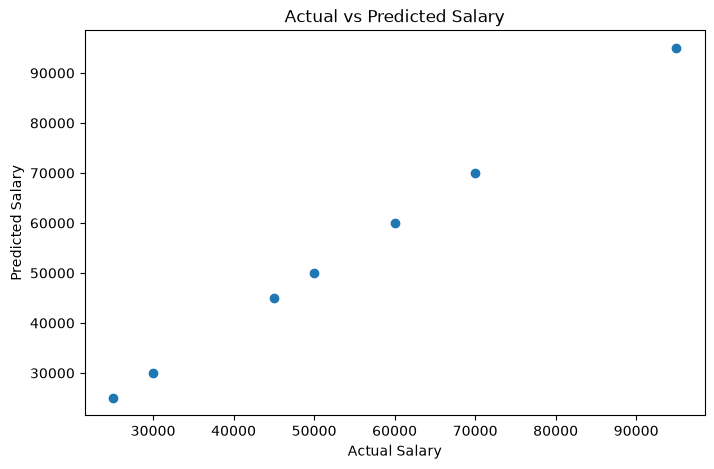

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(Y, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

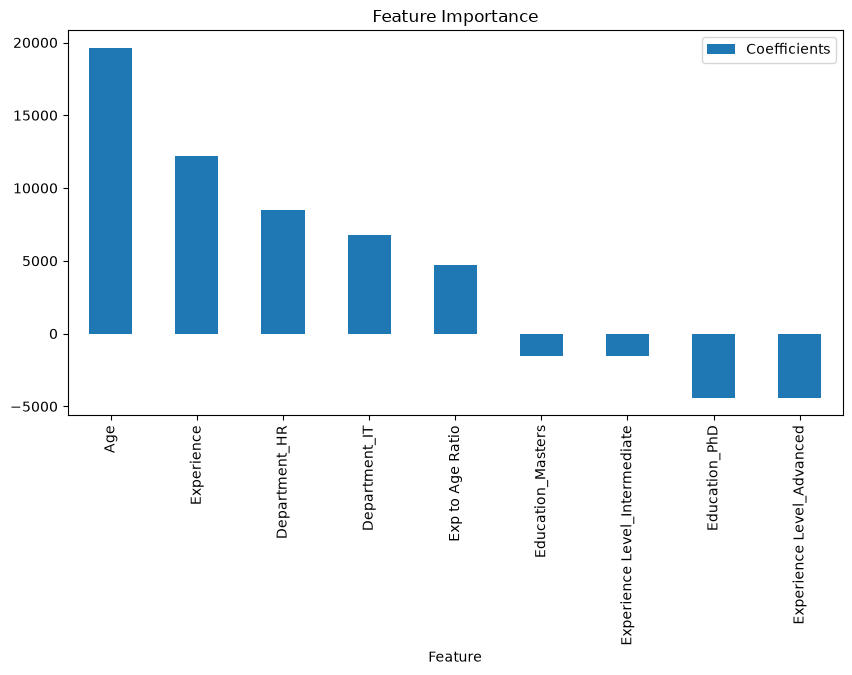

In [22]:
coef_df.sort_values(by="Coefficients", ascending=False).plot(
    x="Feature", y="Coefficients", kind="bar", figsize=(10, 5)
)
plt.title("Feature Importance")
plt.show()